# 3. Other libraries: pytorch, jax, numba

The beamformer of notebook 2, $B(\mathbf{x}) = \sum_\omega \mathbf{s}^H K\, \mathbf{s}$, in three more libraries:

- **pytorch** and **jax**: array libraries like `numpy`, with faster linear algebra, and able to run on GPUs,
- **numba**: compiles plain Python loops, like those of notebook 1, to fast machine code.

Steps 1 and 2 are as before. At the end, we compare the speed of all of them, for the beamformers of notebook 4 as well.

## 1. Geometry

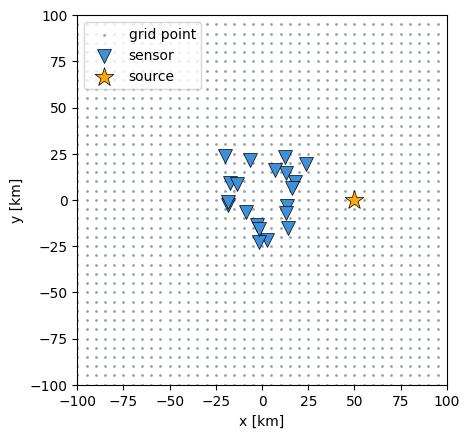

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

# 20 sensors, placed at random in a 50 km x 50 km square
rng = np.random.default_rng(42)
n_sensors = 20
stations = rng.uniform(-25, 25, size=(n_sensors, 2))
source = np.array([50, 0])

# candidate source positions: a grid with 5 km spacing
grid_coords = np.arange(-100, 100, 5)
xx, yy = np.meshgrid(grid_coords, grid_coords, indexing="ij")
gridpoints = np.stack([xx.ravel(), yy.ravel()], axis=1)

fig, ax = plt.subplots()
ax.scatter(*gridpoints.T, s=1, c="#94a4a2", label="grid point")
ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]")
ax.legend(loc="upper left")

## 2. Recordings

The source emits a short pulse. It reaches sensor $j$ after the traveltime $t_j = |\mathbf{r}_j - \mathbf{r}_\text{source}| / c$. In the frequency domain, a delay by $t_j$ is a multiplication with $e^{-i\omega t_j}$. With field data, use the spectra of your recordings instead.

[(0.0, 60.0),
 Text(0.5, 0, 'time [s]'),
 Text(0, 0.5, 'amplitude'),
 Text(0.5, 1.0, 'recordings')]

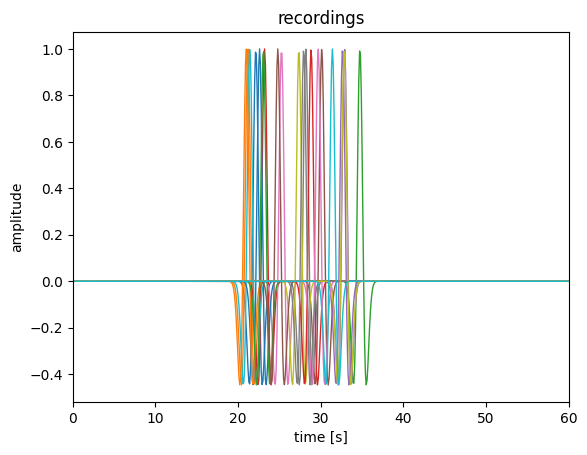

In [2]:
sampling_rate = 10  # Hz
times = np.arange(0, 100, 1 / sampling_rate)  # 100 s
freqs = np.fft.fftfreq(len(times), 1 / sampling_rate)
omega = 2 * np.pi * freqs

medium_velocity = 3  # km/s
traveltimes = np.linalg.norm(stations - source, axis=1) / medium_velocity


def ricker(t, peak_frequency, delay):
    arg = (np.pi * peak_frequency * (t - delay)) ** 2
    return (1 - 2 * arg) * np.exp(-arg)


# every sensor records the same pulse, delayed by its traveltime
pulse_spectrum = np.fft.fft(ricker(times, peak_frequency=0.5, delay=10))
waveform_spectra = pulse_spectrum * np.exp(-1j * omega * traveltimes[:, None])
waveforms = np.fft.ifft(waveform_spectra).real

# we beamform between 0.1 and 1 Hz
band = (freqs > 0.1) & (freqs < 1.0)
omega_band = omega[band]
spectra = waveform_spectra[:, band]

fig, ax = plt.subplots()
ax.plot(times, waveforms.T, lw=1)
ax.set(xlim=(0, 60), xlabel="time [s]", ylabel="amplitude", title="recordings")

## 3. Beamforming with numpy

For reference, the matrix-product version of notebook 2:

In [3]:
def beamform_numpy(stations, gridpoints, omega_band, spectra, medium_velocity):
    traveltimes = np.linalg.norm(gridpoints[:, None, :] - stations[None, :, :], axis=2) / medium_velocity
    beampowers = np.zeros(len(gridpoints))
    for w in range(len(omega_band)):
        # cross-spectral density matrix at this frequency, without the auto-correlations
        K = np.outer(spectra[:, w], spectra[:, w].conj())
        np.fill_diagonal(K, 0)
        s = np.exp(-1j * omega_band[w] * traveltimes)  # steering vectors, (grid points, sensors)
        beampowers += np.sum((s.conj() @ K) * s, axis=1).real  # s^H K s
    return beampowers


title = "numpy"
beampowers = beamform_numpy(stations, gridpoints, omega_band, spectra, medium_velocity)

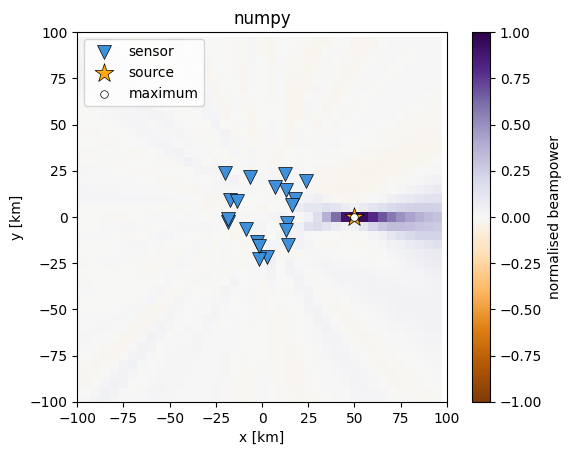

In [4]:
def plot_beampowers(beampowers, title):
    bp = beampowers.reshape(len(grid_coords), len(grid_coords)).T
    bp = bp / np.abs(bp).max()
    fig, ax = plt.subplots()
    pcm = ax.pcolormesh(grid_coords, grid_coords, bp, cmap="PuOr", vmin=-1, vmax=1, shading="nearest")
    ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5, label="sensor")
    ax.scatter(*source, marker="*", s=200, c="#ffa90e", ec="k", lw=0.5, label="source")
    ax.scatter(*gridpoints[np.argmax(beampowers)], marker="o", s=30, c="w", ec="k", lw=0.5, label="maximum")
    fig.colorbar(pcm, label="normalised beampower")
    ax.set(xlim=(-100, 100), ylim=(-100, 100), aspect="equal", xlabel="x [km]", ylabel="y [km]", title=title)
    ax.legend(loc="upper left")


plot_beampowers(beampowers, title)

## 4. pytorch

`pytorch` mirrors `numpy` almost one-to-one (`np.exp` → `torch.exp`, `np.outer` → `torch.outer`). We convert the arrays to `pytorch` tensors and translate the function line by line. With `device="cuda"`, the same function runs on an NVIDIA GPU.

In [5]:
import torch


def beamform_torch(stations, gridpoints, omega_band, spectra, medium_velocity, device="cpu"):
    stations, gridpoints, omega_band, spectra = (
        torch.as_tensor(a, device=device) for a in (stations, gridpoints, omega_band, spectra)
    )
    traveltimes = torch.cdist(gridpoints, stations) / medium_velocity
    beampowers = torch.zeros(len(gridpoints), dtype=torch.float64, device=device)
    for w in range(len(omega_band)):
        K = torch.outer(spectra[:, w], spectra[:, w].conj())
        K.fill_diagonal_(0)
        s = torch.exp(-1j * omega_band[w] * traveltimes)
        beampowers += torch.sum((s.conj() @ K) * s, dim=1).real
    return beampowers.cpu().numpy()


beampowers_torch = beamform_torch(stations, gridpoints.astype(float), omega_band, spectra, medium_velocity)
print("same result as numpy:", np.allclose(beampowers_torch, beampowers))

same result as numpy: True


## 5. jax

`jax.numpy` has the functions of `numpy` under the same names. `jax.jit` compiles a function when it is first called. Here we compile the work for one frequency; `jax` also runs on GPUs.

In [6]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)  # double precision, as numpy


@jax.jit
def one_frequency(d, omega, traveltimes):
    K = jnp.outer(d, d.conj())
    K = K - jnp.diag(jnp.diag(K))
    s = jnp.exp(-1j * omega * traveltimes)
    return jnp.sum((s.conj() @ K) * s, axis=1).real


def beamform_jax(stations, gridpoints, omega_band, spectra, medium_velocity):
    traveltimes = jnp.linalg.norm(gridpoints[:, None, :] - stations[None, :, :], axis=2) / medium_velocity
    spectra = jnp.asarray(spectra)
    beampowers = jnp.zeros(len(gridpoints))
    for w in range(len(omega_band)):
        beampowers += one_frequency(spectra[:, w], omega_band[w], traveltimes)
    return np.asarray(beampowers)


beampowers_jax = beamform_jax(stations, gridpoints, omega_band, spectra, medium_velocity)
print("same result as numpy:", np.allclose(beampowers_jax, beampowers))

same result as numpy: True


## 6. numba

[numba](https://numba.pydata.org) compiles loops. We can write $\mathbf{s}^H K\, \mathbf{s}$ as in notebook 1, grid point by grid point and pair by pair; `numba.prange` spreads the grid points over all cores. No steering vectors of all grid points are stored, only one at a time.

In [7]:
import numba


@numba.njit(parallel=True, fastmath=True)
def beamform_numba(stations, gridpoints, omega_band, spectra, medium_velocity):
    n_sensors, n_freqs = spectra.shape
    beampowers = np.zeros(len(gridpoints))
    for x in numba.prange(len(gridpoints)):
        traveltimes = np.sqrt(((gridpoints[x] - stations) ** 2).sum(axis=1)) / medium_velocity
        for w in range(n_freqs):
            s = np.exp(-1j * omega_band[w] * traveltimes)  # steering vector of this grid point
            for j in range(n_sensors):
                for k in range(n_sensors):
                    if j != k:
                        K_jk = spectra[j, w] * np.conj(spectra[k, w])
                        beampowers[x] += (np.conj(s[j]) * K_jk * s[k]).real
    return beampowers


beampowers_numba = beamform_numba(stations, gridpoints.astype(float), omega_band, spectra, medium_velocity)
print("same result as numpy:", np.allclose(beampowers_numba, beampowers))

same result as numpy: True


## 7. Speed

With 200 sensors, on this computer (the compiled functions have been called once above, so compilation is not timed):

In [8]:
more_stations = rng.uniform(-25, 25, size=(200, 2))
more_spectra = pulse_spectrum[band] * np.exp(
    -1j * omega_band * np.linalg.norm(more_stations - source, axis=1)[:, None] / medium_velocity
)
args = (more_stations, gridpoints.astype(float), omega_band, more_spectra, medium_velocity)

functions = {"numpy": beamform_numpy, "pytorch": beamform_torch, "jax": beamform_jax, "numba": beamform_numba}
if torch.cuda.is_available():
    functions["pytorch, GPU"] = lambda *args: beamform_torch(*args, device="cuda")
for name, beamform in functions.items():
    beamform(*args)  # compiles for the new array shapes, where needed
    start = time.perf_counter()
    beamform(*args)
    print(f"{name:13s} {time.perf_counter() - start:6.3f} s")

numpy          1.587 s


pytorch        0.254 s


jax            0.129 s


numba          0.708 s


pytorch, GPU   0.118 s


These are small problems. For a systematic comparison, `implementations/` holds each version as a file, extended to many time windows, single precision and the beamformers of notebook 4; `tests/` checks that they all give the same result. `benchmarks/run.py` timed them on one computer (2× Intel Xeon Gold 6326 with 32 cores, NVIDIA A40 GPU): 10 000 grid points, 100 time windows of 10 minutes, 0.1–1 Hz (539 frequencies). The time includes everything from the spectra to the map.

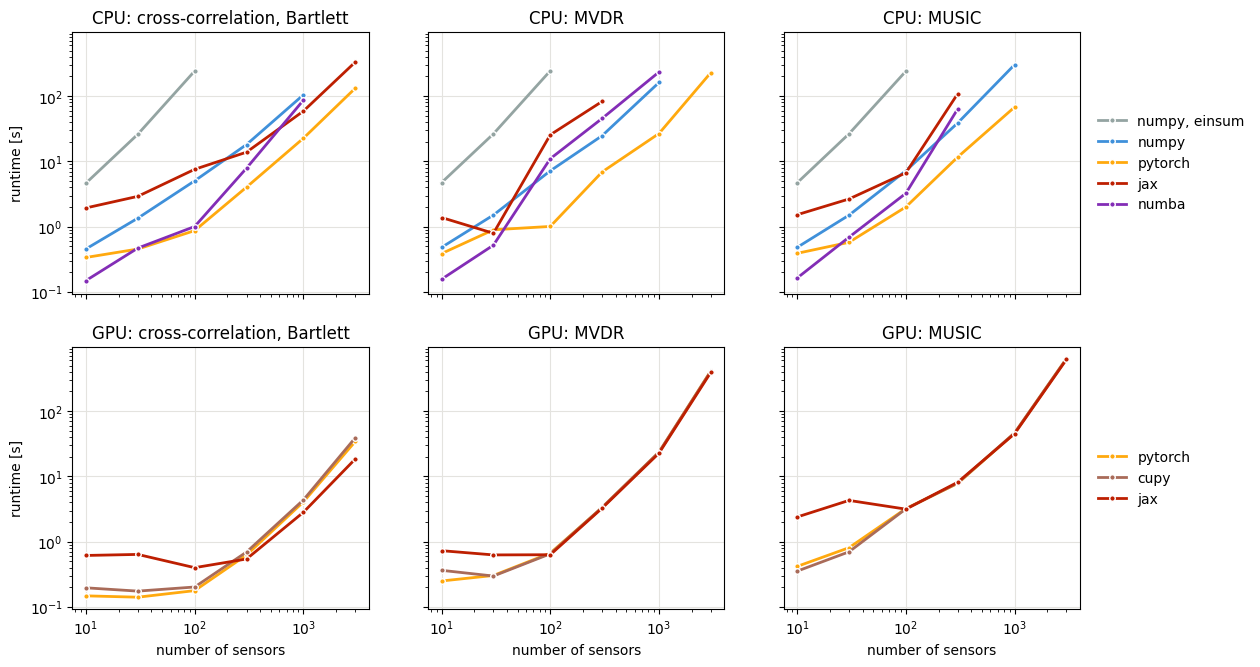

In [9]:
import json
from pathlib import Path

results = json.loads(Path("../results/benchmark.json").read_text())
CASES = {
    "CPU": {
        "numpy_einsum": ("numpy, einsum", "#94a4a2"),
        "numpy_matmul": ("numpy", "#3f90da"),
        "torch_matmul": ("pytorch", "#ffa90e"),
        "jax_matmul_cpu": ("jax", "#bd1f01"),
        "numba_loops": ("numba", "#832db6"),
    },
    "GPU": {
        "torch_matmul_cuda": ("pytorch", "#ffa90e"),
        "cupy_matmul": ("cupy", "#a96b59"),
        "jax_matmul_gpu": ("jax", "#bd1f01"),
    },
}
METHODS = {"crosscorrelation": "cross-correlation, Bartlett", "mvdr": "MVDR", "music": "MUSIC"}

fig, axs = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for row, (hardware, cases) in enumerate(CASES.items()):
    for ax, (method, method_label) in zip(axs[row], METHODS.items()):
        for case, (label, color) in cases.items():
            data = sorted(
                (r["n_sensors"], r["runtime"])
                for r in results["runs"]
                if (r["case"], r["method"], r["window_length"]) == (case, method, 600)
            )
            if data:
                ax.plot(*zip(*data), c=color, lw=2, marker="o", ms=4, mec="w", label=label)
        ax.set(xscale="log", yscale="log", title=f"{hardware}: {method_label}")
        ax.grid(True, color="#e4e3df", lw=0.8)
    axs[row, 0].set_ylabel("runtime [s]")
    axs[row, 2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
for ax in axs[1]:
    ax.set_xlabel("number of sensors")

Seconds for 100 / 1000 sensors, cross-correlation beamformer on the CPU: `numpy` 5.0 / 105, `pytorch` 0.87 / 23, `jax` 7.6 / 59, `numba` 1.0 / 87. `numpy` with `einsum` needs 243 s for 100 sensors.

- **Matrix product instead of `einsum`**: about 50× faster in `numpy`.
- **`pytorch` is the fastest on the CPU, for every beamformer**: 4–7× faster than `numpy`. Its linear algebra uses all cores well, also for the inverse (MVDR) and the eigenvectors (MUSIC) of $K$.
- **`numba`** keeps up with `pytorch` up to about 100 sensors. With more, tuned matrix products win over simple compiled loops. For MVDR and MUSIC, it relies on `numpy` for the inverse and the eigenvectors.
- **`jax`** is slower than `pytorch` on the CPU. On the GPU, `pytorch`, `jax` and `cupy` (`numpy` code on the GPU) are about equally fast.
- **A GPU** is 5× faster than the CPU for cross-correlation (4.1 instead of 23 s with 1000 sensors). For MVDR and MUSIC with 1000 sensors it gains little (23 instead of 27 s, 46 instead of 68 s): there, the inverse and the eigenvectors of $K$ take most of the time.
- The grid search grows with $n_\text{sensors}^2$, the inverse and the eigenvectors with $n_\text{sensors}^3$.

So: start with `numpy`, and when it becomes slow, change a few lines to `pytorch`.